den store fil 

## vi har nu:

# Preprocessing
import af alle predictors
averaging til én værdi per år
kombination baseret på valgåret

# modelling
en simpel OLS model - med flere sæt predictors

# evaluation
En LOOCV



### vi mangler:
# Preprocessing
(en mere sofistikeret vægtning når flere  målinger pr år)
interpolation af manglende år
kombination baseret på alle år, evt baseret på vægte estimeret ved regression (eller en model der kan have en højere resolution i x end i y)

# Modelling
En analyse af colinearity/kombination af variable for at komme af med den
en ols model rafineret efter chapt 6
en form for bayesian regression eller noget?
En form for tree based method

# Evaluation
En leave future out validation (der er mange valg her fx ift om man kun skal evaluere på nogle få valg og om man skal fjerne det seenste)

en analyse af hvilke predictors der er vigtige og hvad det  btyder

In [74]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import sklearn

In [75]:
import os

In [76]:
os.getcwd()

'c:\\Users\\carle\\Documents\\Cognitive_Science\\MASTER\\Data science\\Data science exam'

In [77]:
gini = pd.read_csv('data/gini.csv', index_col=0, skiprows=3)
gdp = pd.read_csv('data/gdp.csv', index_col=0, skiprows=3)
inflation = pd.read_csv('data/inflation.csv', index_col=0, skiprows=3)
unemployment = pd.read_csv('data/unemployment.csv', index_col=0, skiprows=3)

In [78]:
gdp.head()

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.485815,3.048518,0.951664,-23.466273,15.675519,11.038520,7.657640,6.181751,NaN,NaN
Africa Eastern and Southern,AFE,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,-2.182395,5.075379,2.795642,1.790384,2.225029,1.922442,...,0.000238,-0.064991,-0.709407,-5.405934,1.844404,1.068005,-0.604582,0.253854,NaN,NaN
Afghanistan,AFG,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.195570,-1.713743,0.856295,-5.382515,-22.584482,-7.576669,0.106093,NaN,NaN,NaN
Africa Western and Central,AFW,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,-0.251185,1.538542,4.740660,3.086962,1.823450,-3.703529,...,-0.355283,0.330202,0.792058,-6.003416,0.154018,2.064401,1.218110,2.107058,NaN,NaN
Angola,AGO,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-3.622865,-3.968525,-3.529000,-7.127615,-1.094341,0.991407,-1.808703,1.292933,NaN,NaN


In [79]:
gini, gdp, inflation, unemployment = [
    df.loc[['United States']]
    for df in [gini, gdp, inflation, unemployment]
]

In [80]:
gini, gdp, inflation, unemployment = [
    df.drop(columns=["Country Code", "Indicator Name", "Indicator Code", "Unnamed: 70"])
    for df in [gini, gdp, inflation, unemployment]
]

In [81]:
gini, gdp, inflation, unemployment = [
    df.melt(var_name="year", value_name=name)
    for df, name in zip(
        [gini, gdp, inflation, unemployment],
        ["gini", "gdp", "inflation", "unemployment"]
    )
]

In [82]:
gini['year'], gdp['year'], inflation['year'], unemployment['year'] = [
    df["year"].astype(int)
    for df in [gini, gdp, inflation, unemployment]
]

In [83]:
gdp

,year,gdp
0,1960,NaN
1,1961,0.618121
2,1962,4.480669
3,1963,2.908272
4,1964,4.340549
...,...,...
61,2021,5.888341
62,2022,1.923862
63,2023,2.035600
64,2024,1.794192


In [84]:
income = pd.read_csv('data/Real wage.csv')
satisfaction = pd.read_csv('data/satisfaction.csv')

In [85]:
income['median_real_wage'] = income['LES1252881600Q']

In [86]:
income['year'] = income['observation_date'].str[:4]
income.head()

,observation_date,LES1252881600Q,median_real_wage,year
0,1979-01-01,335.0,335.0,1979
1,1979-04-01,335.0,335.0,1979
2,1979-07-01,330.0,330.0,1979
3,1979-10-01,326.0,326.0,1979
4,1980-01-01,321.0,321.0,1980


In [87]:
satisfaction['year'] = satisfaction['In general, are you satisfied or dissatisfied with the way things are going in [your personal life/the United States] at this time? <br><b>% Satisfied</b>'].str[-4:]

In [88]:
yearly_wage = income.groupby('year')['median_real_wage'].mean()
yearly_pers = satisfaction.groupby('year')['Personal life'].mean()
yearly_us = satisfaction.groupby('year')['United States'].mean()

In [89]:
yearly_wage = pd.DataFrame(index= yearly_wage.index, data=yearly_wage.values, columns=['wage'])
yearly_pers = pd.DataFrame(index= yearly_pers.index, data=yearly_pers.values, columns=['pers'])
yearly_us = pd.DataFrame(index= yearly_us.index, data=yearly_us.values, columns=['us'])

In [90]:
yearly_wage.reset_index(inplace=True)
yearly_pers.reset_index(inplace=True)
yearly_us.reset_index(inplace=True)


In [91]:
yearly_pers.head()

,year,pers
0,1979,76.333333
1,1981,81.000000
2,1982,75.500000
3,1983,77.000000
4,1984,79.000000


In [92]:
election_results = pd.read_csv('data/election_results.csv')

In [93]:
election_results.head()

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain


In [94]:
prediction_data = pd.merge(election_results, gini, how = 'left', on=['year'])

In [95]:
prediction_data = pd.merge(prediction_data, gdp, how = 'left', on=['year'])

In [96]:
prediction_data = pd.merge(prediction_data, unemployment, how = 'left', on=['year'])

In [97]:
prediction_data = pd.merge(prediction_data, inflation, how = 'left', on=['year'])

In [98]:
yearly_wage['year'] = yearly_wage['year'].astype(int)
yearly_pers['year'] = yearly_pers['year'].astype(int)
yearly_us['year'] = yearly_us['year'].astype(int)

In [99]:
prediction_data = pd.merge(prediction_data, yearly_wage, how = 'left', on=['year'])
prediction_data = pd.merge(prediction_data, yearly_pers, how = 'left', on=['year'])
prediction_data = pd.merge(prediction_data, yearly_us, how = 'left', on=['year'])

In [100]:
prediction_data = prediction_data.dropna()

In [101]:
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.8,1.794192,4.022,2.949525,369.50,78.0,20.0
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,40.0,-2.561807,8.055,1.233584,380.00,90.0,41.0
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.3,1.022666,4.869,1.261583,346.75,85.0,23.0
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.1,-0.828888,5.784,3.839100,335.25,80.0,10.0
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.5,2.891111,5.529,2.677237,337.50,84.0,45.0
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.1,2.925863,3.992,3.376857,334.25,87.0,62.0
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.3,2.572464,5.451,2.931204,312.75,86.0,41.0
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.4,2.096669,7.500,3.028820,313.50,78.0,22.5
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.7,3.235338,5.500,4.077741,325.75,86.5,48.5
10,1984,2,2,Republican,58.80,40.60,Republican,Ronald Reagan,Walter Mondale,37.3,6.311989,7.500,4.300535,313.50,79.0,51.0


In [102]:
from sklearn.preprocessing import StandardScaler
scaled_prediction_data = prediction_data.copy()

cols_to_scale = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'popular vote for incumbent party']  # standardizing predictors that are not categroical and the outcome

sc = StandardScaler()
scaled_prediction_data[cols_to_scale] = sc.fit_transform(scaled_prediction_data[cols_to_scale])

scaled_prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,-0.073021,49.81,Republican,Donald Trump,Kamala Harris,1.332837,-0.066626,-1.324092,-0.018145,1.484465,-1.316979,-1.043528
1,2020,1,1,Republican,-0.357421,51.31,Democratic,Joe Biden,Donald Trump,0.102526,-1.978906,1.645579,-1.738985,1.962224,1.636993,0.292697
2,2016,3,1,Democratic,-0.099924,46.20,Republican,Donald Trump,Hillary Clinton,0.991084,-0.405325,-0.700409,-1.710906,0.449321,0.406171,-0.852639
4,2008,3,1,Republican,-0.580328,52.90,Democratic,Barack Obama,John McCain,0.854383,-1.218156,-0.026656,0.873969,-0.073939,-0.824651,-1.679826
5,2004,2,2,Republican,0.380480,48.30,Republican,George W. Bush,John Kerry,0.444279,0.414921,-0.214423,-0.291211,0.028438,0.160007,0.547216
6,2000,3,1,Democratic,-0.061492,47.90,Republican,George W. Bush,Al Gore,0.170877,0.430176,-1.346182,0.410407,-0.119440,0.898500,1.628922
7,1996,2,2,Democratic,0.092238,40.70,Democratic,Bill Clinton,Bob Dole,0.307578,0.275035,-0.271858,-0.036519,-1.097708,0.652335,0.292697
8,1992,4,2,Republican,-2.175270,43.00,Democratic,Bill Clinton,George H. W. Bush,-0.991084,0.066161,1.236909,0.061376,-1.063582,-1.316979,-0.884454
9,1988,3,1,Republican,0.937749,45.60,Republican,George H. W. Bush,Michael Dukakis,-1.469538,0.566036,-0.235777,1.113292,-0.506197,0.775418,0.769920
10,1984,2,2,Republican,1.936989,40.60,Republican,Ronald Reagan,Walter Mondale,-1.742941,1.916683,1.236909,1.336722,-1.063582,-1.070815,0.928995


In [103]:
scaled_prediction_data.dtypes

year                                                        int64
prospective conscutive term for incumbent party             int64
prospective 1st/2nd term for incumbent party candidate      int64
incumbent party                                            object
popular vote for incumbent party                          float64
popular vote for non-incumbent party                      float64
winner party                                               object
winner president                                           object
loser                                                      object
gini                                                      float64
gdp                                                       float64
unemployment                                              float64
inflation                                                 float64
wage                                                      float64
pers                                                      float64
us        

In [104]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder(categories=[['1', '2', '3', '4']])  # specify order
scaled_prediction_data['prospective conscutive term for incumbent party'] = enc.fit_transform(scaled_prediction_data[['prospective conscutive term for incumbent party']])

enc = OrdinalEncoder(categories=[['1', '2']])  # specify order
scaled_prediction_data['prospective 1st/2nd term for incumbent party candidate'] = enc.fit_transform(scaled_prediction_data[['prospective 1st/2nd term for incumbent party candidate']]) #,aybe we should introduce a varibale reflecting the presence of populist candidates, or something regaridn the non-incumbent candidates

In [105]:
scaled_prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,0.0,0.0,Democratic,-0.073021,49.81,Republican,Donald Trump,Kamala Harris,1.332837,-0.066626,-1.324092,-0.018145,1.484465,-1.316979,-1.043528
1,2020,0.0,0.0,Republican,-0.357421,51.31,Democratic,Joe Biden,Donald Trump,0.102526,-1.978906,1.645579,-1.738985,1.962224,1.636993,0.292697
2,2016,2.0,0.0,Democratic,-0.099924,46.20,Republican,Donald Trump,Hillary Clinton,0.991084,-0.405325,-0.700409,-1.710906,0.449321,0.406171,-0.852639
4,2008,2.0,0.0,Republican,-0.580328,52.90,Democratic,Barack Obama,John McCain,0.854383,-1.218156,-0.026656,0.873969,-0.073939,-0.824651,-1.679826
5,2004,1.0,1.0,Republican,0.380480,48.30,Republican,George W. Bush,John Kerry,0.444279,0.414921,-0.214423,-0.291211,0.028438,0.160007,0.547216
6,2000,2.0,0.0,Democratic,-0.061492,47.90,Republican,George W. Bush,Al Gore,0.170877,0.430176,-1.346182,0.410407,-0.119440,0.898500,1.628922
7,1996,1.0,1.0,Democratic,0.092238,40.70,Democratic,Bill Clinton,Bob Dole,0.307578,0.275035,-0.271858,-0.036519,-1.097708,0.652335,0.292697
8,1992,3.0,1.0,Republican,-2.175270,43.00,Democratic,Bill Clinton,George H. W. Bush,-0.991084,0.066161,1.236909,0.061376,-1.063582,-1.316979,-0.884454
9,1988,2.0,0.0,Republican,0.937749,45.60,Republican,George H. W. Bush,Michael Dukakis,-1.469538,0.566036,-0.235777,1.113292,-0.506197,0.775418,0.769920
10,1984,1.0,1.0,Republican,1.936989,40.60,Republican,Ronald Reagan,Walter Mondale,-1.742941,1.916683,1.236909,1.336722,-1.063582,-1.070815,0.928995


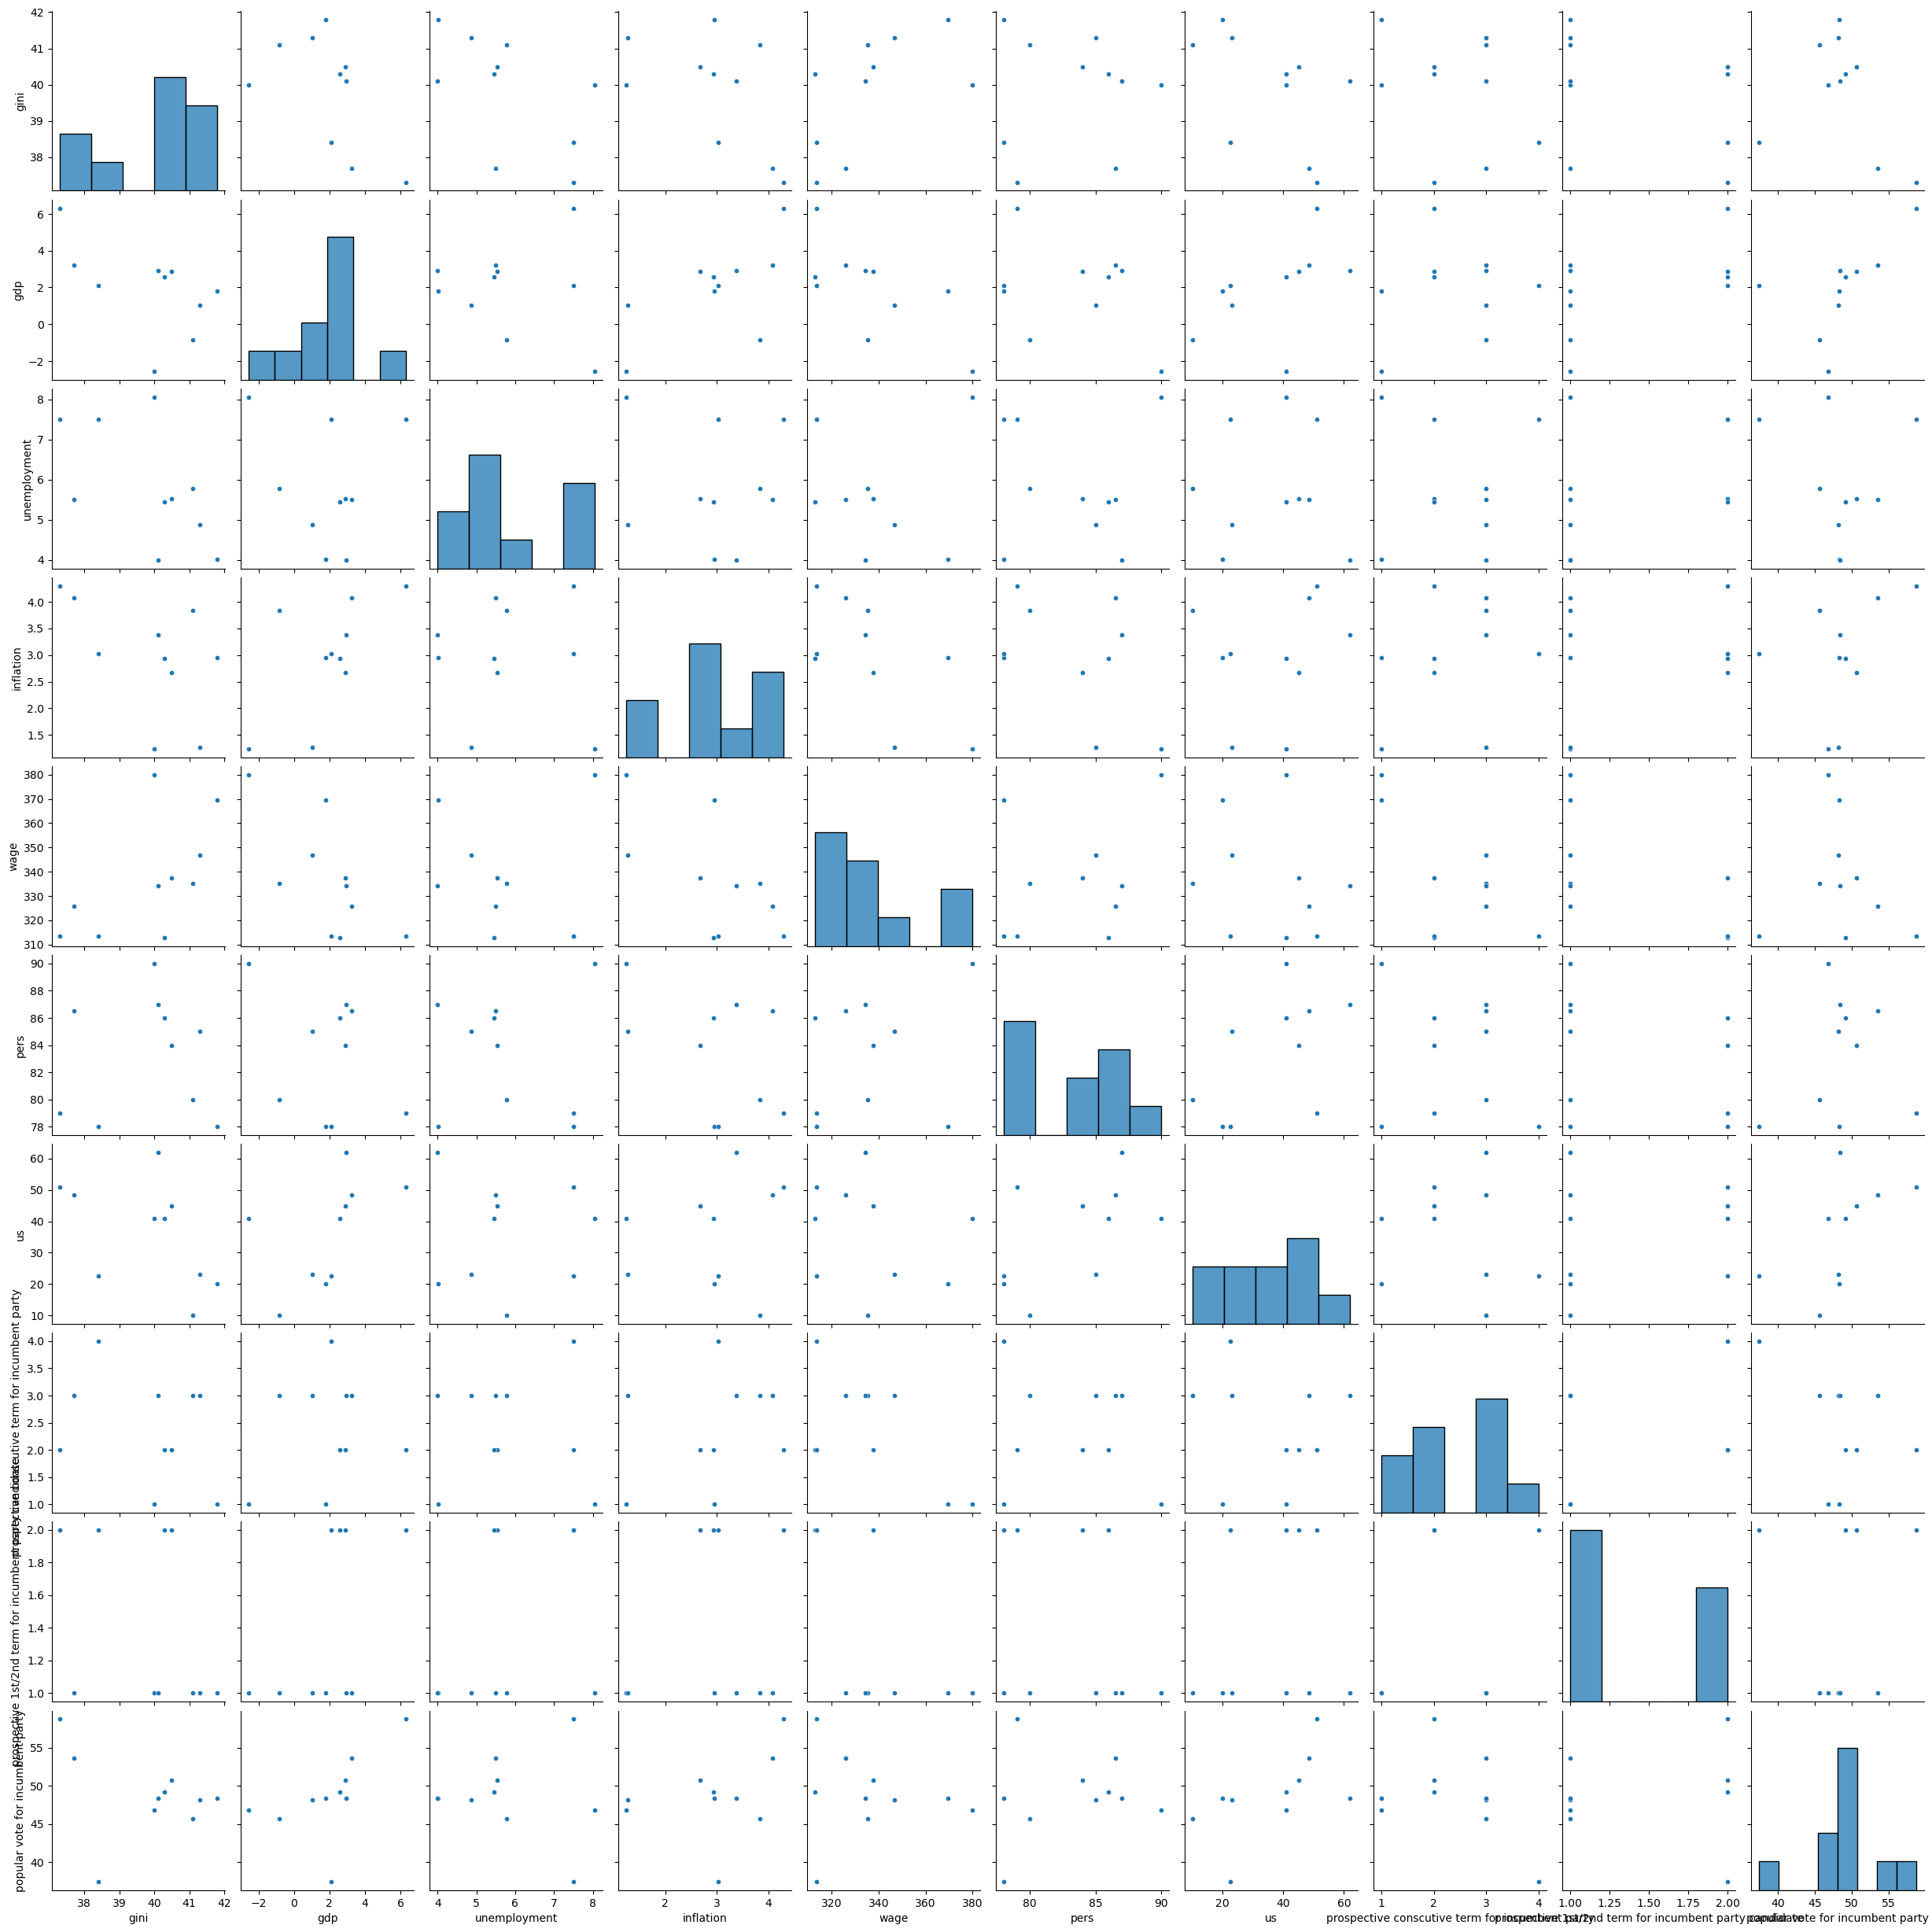

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate', 'popular vote for incumbent party']

sns.pairplot(prediction_data[cols], plot_kws={'alpha': 1, 's': 20})
plt.show()

problems from the book:
1. Non-linearity of the response-predictor relationships. 
2. Correlation of error terms. 
3. Non-constant variance of error terms. 
4. Outliers. 
5. High-leverage points. 
6. Collinearity. - decreases accuracy -indentifiability problems
and thus rreduces power of the test, increases p values

In [106]:
import statsmodels.api as sm

In [107]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS ,
summarize ,
poly)

In [108]:
X = scaled_prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]

In [109]:
Y = prediction_data['popular vote for incumbent party']
model = sm.OLS(Y, X)
results = model.fit()

In [110]:
results.summary()

c:\Users\carle\miniconda3\envs\datasci\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                        OLS Regression Results                                       
=====================================================================================================
Dep. Variable:     popular vote for incumbent party   R-squared (uncentered):                   0.980
Model:                                          OLS   Adj. R-squared (uncentered):              0.801
Method:                               Least Squares   F-statistic:                              5.468
Date:                              Sat, 16 May 2026   Prob (F-statistic):                       0.321
Time:                                      15:33:04   Log-Likelihood:                         -33.526
No. Observations:                                10   AIC:                                      85.05
Df Residuals:                                     1   BIC:                                      87.77
Df Model:                                         9                                                  
Covariance Type:                          nonrobust                                                  
==========================================================================================================================
                                                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
gini                                                      23.0268     30.949      0.744      0.593    -370.220     416.274
gdp                                                       44.6810     33.452      1.336      0.409    -380.365     469.727
unemployment                                              20.8481     27.963      0.746      0.592    -334.453     376.149
inflation                                                 29.5123     15.408      1.915      0.306    -166.259     225.284
wage                                                      45.5218     14.074      3.234      0.191    -133.307     224.351
pers                                                      39.3468     23.741      1.657      0.346    -262.306     341.000
us                                                       -25.7761     22.569     -1.142      0.458    -312.544     260.991
prospective conscutive term for incumbent party           24.7330      8.772      2.819      0.217     -86.729     136.195
prospective 1st/2nd term for incumbent party candidate    32.7975     28.852      1.137      0.459    -333.801     399.396
==============================================================================
Omnibus:                        7.845   Durbin-Watson:                   1.790
Prob(Omnibus):                  0.020   Jarque-Bera (JB):                3.002
Skew:                          -1.174   Prob(JB):                        0.223
Kurtosis:                       4.301   Cond. No.                         16.6
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [111]:
summarize(results)

c:\Users\carle\miniconda3\envs\datasci\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


,coef,std err,t,P>|t|
gini,23.0268,30.949,0.744,0.593
gdp,44.6810,33.452,1.336,0.409
unemployment,20.8481,27.963,0.746,0.592
inflation,29.5123,15.408,1.915,0.306
wage,45.5218,14.074,3.234,0.191
pers,39.3468,23.741,1.657,0.346
us,-25.7761,22.569,-1.142,0.458
prospective conscutive term for incumbent party,24.7330,8.772,2.819,0.217
prospective 1st/2nd term for incumbent party candidate,32.7975,28.852,1.137,0.459


In [116]:
from functools import partial
from sklearn.model_selection import \
(cross_validate ,
KFold ,
ShuffleSplit)
from sklearn.base import clone
from ISLP.models import sklearn_sm

In [120]:
X = MS(['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']).fit_transform(scaled_prediction_data)
Y = prediction_data['popular vote for incumbent party']

model = sklearn_sm(sm.OLS, MS(['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']))
results = model.fit(X, Y)
predictions = model.predict(X)

cv_results = cross_validate(model ,
X,
Y,
cv = scaled_prediction_data.shape [0])
cv_err = np.mean(cv_results['test_score'])
cv_err

np.float64(426.5932716226249)

In [121]:
X = MS(['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us']).fit_transform(scaled_prediction_data)

model = sklearn_sm(sm.OLS, MS(['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us']))
results = model.fit(X, Y)
predictions = model.predict(X)

cv_results = cross_validate(model ,
X,
Y,
cv = scaled_prediction_data.shape [0])
cv_err = np.mean(cv_results['test_score'])
cv_err

np.float64(71.6369868591528)

In [122]:
X = MS(['gini', 'gdp', 'unemployment', 'inflation', 'wage']).fit_transform(scaled_prediction_data)

model = sklearn_sm(sm.OLS, MS(['gini', 'gdp', 'unemployment', 'inflation', 'wage']))
results = model.fit(X, Y)
predictions = model.predict(X)

cv_results = cross_validate(model ,
X,
Y,
cv = scaled_prediction_data.shape [0])
cv_err = np.mean(cv_results['test_score'])
cv_err

np.float64(118.93052146366139)

In [123]:
X = MS(['pers', 'us']).fit_transform(scaled_prediction_data)

model = sklearn_sm(sm.OLS, MS(['pers', 'us']))
results = model.fit(X, Y)
predictions = model.predict(X)

cv_results = cross_validate(model ,
X,
Y,
cv = scaled_prediction_data.shape [0])
cv_err = np.mean(cv_results['test_score'])
cv_err

np.float64(44.00889024604295)